# Modelagem 🤖
### Cancelamento de Serviços — Empresa de Saneamento

**Objetivo:** Treinar e comparar modelos de classificação binária para prever o cancelamento de ordens de serviço no momento da sua abertura.

**Métricas principais:** AUC-ROC e Average Precision (PR-AUC) — a acurácia isolada não é usada por ser enganosa em datasets desbalanceados.


# 📋 1. Setup e Carregamento

Nesta etapa, o dataset de features gerado no notebook anterior é carregado e dividido em treino e teste com estratificação pelo target, preservando a proporção de cancelamentos em ambos os conjuntos.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    ConfusionMatrixDisplay, classification_report,
)
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
FIGURES = Path('../reports/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Carrega dataset de features
df = pd.read_parquet('../data/processed/features_modelo.parquet')

TARGET = 'cancelado'
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

# DATA_REG foi salva apenas para o corte temporal — não é feature do modelo
FEATURES = [c for c in FEATURES if c != 'DATA_REG']

# Colunas categóricas — receberão TargetEncoder dentro do pipeline
CAT_COLS = ['GRUPO_SERVICO_OPERACIONAL', 'COD_AREA_SERVICO', 'COD_SERVICO_ETAPA']
# Colunas numéricas — passadas diretamente (ou com StandardScaler para LR)
NUM_COLS = [c for c in FEATURES if c not in CAT_COLS]

print(f'Shape: {df.shape}')
print(f'Features numéricas ({len(NUM_COLS)}): {NUM_COLS}')
print(f'Features categóricas ({len(CAT_COLS)}): {CAT_COLS}')
print(f'Taxa de cancelamento: {y.mean():.2%}')


Shape: (54613, 17)
Features numéricas (12): ['prazo_horas', 'priori_num', 'hora_abertura', 'dia_semana_num', 'mes', 'fim_de_semana', 'fora_horario_com', 'hist_n_ordens', 'hist_n_cancelamentos', 'hist_taxa_cancelamento', 'hist_recencia_dias', 'hist_reincidencia_90d']
Features categóricas (3): ['GRUPO_SERVICO_OPERACIONAL', 'COD_AREA_SERVICO', 'COD_SERVICO_ETAPA']
Taxa de cancelamento: 30.25%


💡 **Observação:**

| Conjunto | Registros | Taxa de cancelamento |
|---------|-----------|---------------------|
| Total | 54.613 | 30,25% |

A separação treino/teste será feita na próxima seção com **corte temporal** — o modelo treina em dados passados e é avaliado em dados futuros, respeitando a ordem natural do problema em produção.


# 📅 2. Separação Temporal Treino / Teste

Nesta etapa, os dados são divididos com base no **tempo**, não aleatoriamente. O modelo é treinado em ordens abertas até dezembro/2019 e avaliado em ordens de janeiro a abril/2020 — simulando exatamente o cenário de produção, onde sempre se prevê o futuro com base no passado.

Uma divisão aleatória ignoraria a dimensão temporal: uma ordem de jan/2018 poderia cair no conjunto de validação enquanto ordens de dez/2019 estariam no treino — o modelo 'veria o futuro', produzindo scores otimistas.


In [2]:
# Corte temporal: treino até dez/2019, teste a partir de jan/2020
CORTE = pd.Timestamp('2020-01-01')

mask_train = df['DATA_REG'] < CORTE
mask_test  = df['DATA_REG'] >= CORTE

X_train = df.loc[mask_train, FEATURES]
X_test  = df.loc[mask_test,  FEATURES]
y_train = df.loc[mask_train, TARGET]
y_test  = df.loc[mask_test,  TARGET]

print(f'Treino: {X_train.shape[0]:,} ordens  '
      f'({df.loc[mask_train, "DATA_REG"].min().date()} → '
      f'{df.loc[mask_train, "DATA_REG"].max().date()})')
print(f'Teste:  {X_test.shape[0]:,} ordens  '
      f'({df.loc[mask_test,  "DATA_REG"].min().date()} → '
      f'{df.loc[mask_test,  "DATA_REG"].max().date()})')
print()
print(f'Taxa cancelamento — Treino: {y_train.mean():.2%}')
print(f'Taxa cancelamento — Teste:  {y_test.mean():.2%}')
print(f'\nProporção treino/teste: {len(X_train)/len(df):.0%} / {len(X_test)/len(df):.0%}')


Treino: 47,640 ordens  (2018-04-01 → 2019-12-31)
Teste:  6,973 ordens  (2020-01-01 → 2020-04-27)

Taxa cancelamento — Treino: 30.10%
Taxa cancelamento — Teste:  31.31%

Proporção treino/teste: 87% / 13%


💡 **Observação:**

| Conjunto | Período | Registros | Taxa cancelamento |
|---------|---------|-----------|------------------|
| **Treino** | Abr/2018 → Dez/2019 | ~46.000 | ~30% |
| **Teste** | Jan/2020 → Abr/2020 | ~8.600 | ~30% |

A taxa de cancelamento é similar nos dois conjuntos — o corte temporal não gerou desvio de distribuição do target, o que é um bom sinal.

O CV estratificado será aplicado **apenas sobre o conjunto de treino**. O conjunto de teste permanece intocado até a avaliação final.


# 🔧 3. Função de Avaliação

Nesta etapa, é definida a função central de avaliação por validação cruzada estratificada. Todos os modelos passarão pela mesma função para garantir comparação justa.


In [3]:
def avaliar_modelo(nome, modelo, X, y, cv=5):
    """
    Avalia um modelo com StratifiedKFold e retorna métricas consolidadas.
    Retorna dict com médias e desvios de AUC-ROC e Average Precision.
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)

    resultados = cross_validate(
        modelo, X, y, cv=skf,
        scoring=['roc_auc', 'average_precision'],
        return_train_score=False,
        n_jobs=-1,
    )

    metricas = {
        'modelo':       nome,
        'auc_roc':      resultados['test_roc_auc'].mean(),
        'auc_roc_std':  resultados['test_roc_auc'].std(),
        'avg_precision':     resultados['test_average_precision'].mean(),
        'avg_precision_std': resultados['test_average_precision'].std(),
    }

    print(f"\n{'='*55}")
    print(f"Modelo: {nome}")
    print(f"  AUC-ROC:          {metricas['auc_roc']:.4f} ± {metricas['auc_roc_std']:.4f}")
    print(f"  Average Precision: {metricas['avg_precision']:.4f} ± {metricas['avg_precision_std']:.4f}")

    return metricas


resultados_comparacao = []  # acumula métricas de todos os modelos


def make_preprocessor(scale_numeric=False):
    """
    Cria o ColumnTransformer com TargetEncoder para categóricas.
    O TargetEncoder do sklearn recalcula o encoding a cada fold do CV,
    eliminando o leakage que ocorreria com encoding pré-computado.

    scale_numeric=True: adiciona StandardScaler nas numéricas (necessário para LR).
    """
    numeric_transformer = StandardScaler() if scale_numeric else 'passthrough'
    return ColumnTransformer([
        ('te',  TargetEncoder(target_type='binary'), CAT_COLS),
        ('num', numeric_transformer,                 NUM_COLS),
    ])


# 🎲 4. Baseline — DummyClassifier

Nesta etapa, é treinado o modelo mais simples possível: o `DummyClassifier` com estratégia `most_frequent`, que sempre prevê a classe majoritária (não cancela). Qualquer modelo útil deve superar esse número — ele define o **piso de performance**.


In [4]:
# DummyClassifier não usa features — pipeline sem preprocessamento
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
m = avaliar_modelo('DummyClassifier', dummy, X_train, y_train)
resultados_comparacao.append(m)



Modelo: DummyClassifier
  AUC-ROC:          0.5000 ± 0.0000
  Average Precision: 0.3010 ± 0.0000


💡 **Observação:**

O `DummyClassifier` com `most_frequent` sempre prevê classe 0 (não cancela). Por isso seu AUC-ROC é exatamente **0,50** — equivalente a chute aleatório. A Average Precision será próxima à taxa base de cancelamento (~0,30), representando um classificador sem nenhuma capacidade discriminativa.

Todo modelo treinado nas próximas seções deve superar esses valores.


# 📈 5. Baseline 2 — Regressão Logística

Nesta etapa, é treinada a Regressão Logística — o modelo linear de referência. Por ser linear, captura apenas relações diretas entre features e target, mas é rápido, interpretável e estabelece um **patamar de complexidade mínima** para justificar modelos mais complexos.

O `StandardScaler` é necessário porque a regressão logística é sensível à escala das features — `prazo_horas` (24–240) e `hist_recencia_dias` têm escalas muito diferentes de features binárias (0–1).


In [5]:
# scale_numeric=True: StandardScaler nas numéricas (LR é sensível à escala)
# TargetEncoder recalcula o encoding a cada fold — sem leakage
lr = Pipeline([
    ('pre', make_preprocessor(scale_numeric=True)),
    ('clf', LogisticRegression(
        max_iter=500,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])

m = avaliar_modelo('Regressão Logística', lr, X_train, y_train)
resultados_comparacao.append(m)



Modelo: Regressão Logística
  AUC-ROC:          0.7366 ± 0.0072
  Average Precision: 0.5078 ± 0.0074


💡 **Observação:**

O `class_weight='balanced'` ajusta automaticamente os pesos das classes inversamente proporcional à sua frequência — equivale a dar mais importância aos cancelamentos (classe minoritária) durante o treino.

A performance da regressão logística define o **ganho obtido com não-linearidade**: se Random Forest e XGBoost não superarem significativamente, o problema pode ser aproximado com um modelo linear mais simples e interpretável.


# 🌳 6. Random Forest

Nesta etapa, é treinado o Random Forest — ensemble de árvores de decisão que captura não-linearidades e interações entre features sem necessidade de scaling. É robusto a outliers e fornece importância de features nativamente.


In [6]:
# Árvores não precisam de scaling — passthrough nas numéricas
rf = Pipeline([
    ('pre', make_preprocessor(scale_numeric=False)),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

m = avaliar_modelo('Random Forest', rf, X_train, y_train)
resultados_comparacao.append(m)



Modelo: Random Forest
  AUC-ROC:          0.7646 ± 0.0080
  Average Precision: 0.5412 ± 0.0102


💡 **Observação:**

| Hiperparâmetro | Valor | Justificativa |
|---|---|---|
| `n_estimators` | 200 | Balanço entre performance e tempo de treino |
| `max_depth` | 10 | Evita overfitting em datasets com ~55k linhas |
| `min_samples_leaf` | 20 | Folhas com no mínimo 20 amostras — regularização |
| `class_weight` | balanced | Compensa desbalanceamento 70/30 |

Esses hiperparâmetros são um ponto de partida razoável. Tuning fino será feito após a comparação inicial entre modelos.


# ⚡ 7. XGBoost

Nesta etapa, é treinado o XGBoost — gradient boosting que constrói árvores sequencialmente, cada uma corrigindo os erros da anterior. É o modelo com maior expectativa de performance e o mais utilizado em competições e projetos de classificação tabular.

O parâmetro `scale_pos_weight` substitui o `class_weight='balanced'` do sklearn e é calculado como `n_negativos / n_positivos`.


In [7]:
# scale_pos_weight: razão entre classe negativa e positiva
# Informa ao XGBoost para dar mais peso aos cancelamentos
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos:.2f}')

xgb = Pipeline([
    ('pre', make_preprocessor(scale_numeric=False)),
    ('clf', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        random_state=RANDOM_STATE,
        eval_metric='aucpr',
        verbosity=0,
        n_jobs=-1,
    )),
])

m = avaliar_modelo('XGBoost', xgb, X_train, y_train)
resultados_comparacao.append(m)


scale_pos_weight: 2.32

Modelo: XGBoost
  AUC-ROC:          0.7660 ± 0.0071
  Average Precision: 0.5460 ± 0.0097


💡 **Observação:**

| Hiperparâmetro | Valor | Justificativa |
|---|---|---|
| `n_estimators` | 300 | Mais árvores que RF pois cada uma é mais fraca |
| `learning_rate` | 0.05 | Taxa de aprendizado conservadora — reduz overfitting |
| `subsample` | 0.8 | 80% das amostras por árvore — regularização |
| `colsample_bytree` | 0.8 | 80% das features por árvore — regularização |
| `scale_pos_weight` | ~2.3 | Razão neg/pos — equivalente ao class_weight balanced |
| `eval_metric` | aucpr | Otimiza Average Precision durante o treino |


# 📊 8. Comparação dos Modelos

Nesta etapa, os resultados de todos os modelos são consolidados em uma tabela comparativa e visualizados graficamente para facilitar a escolha do modelo campeão.


In [8]:
df_resultados = pd.DataFrame(resultados_comparacao).set_index('modelo')
print('=== Comparação de Modelos ===')
display(df_resultados.style.highlight_max(
    subset=['auc_roc', 'avg_precision'], color='lightgreen'
))


=== Comparação de Modelos ===


,auc_roc,auc_roc_std,avg_precision,avg_precision_std
modelo,,,,
DummyClassifier,0.500000,0.000000,0.301008,0.000000
Regressão Logística,0.736572,0.007188,0.507815,0.007423
Random Forest,0.764628,0.008018,0.541206,0.010233
XGBoost,0.765961,0.007073,0.546022,0.009675


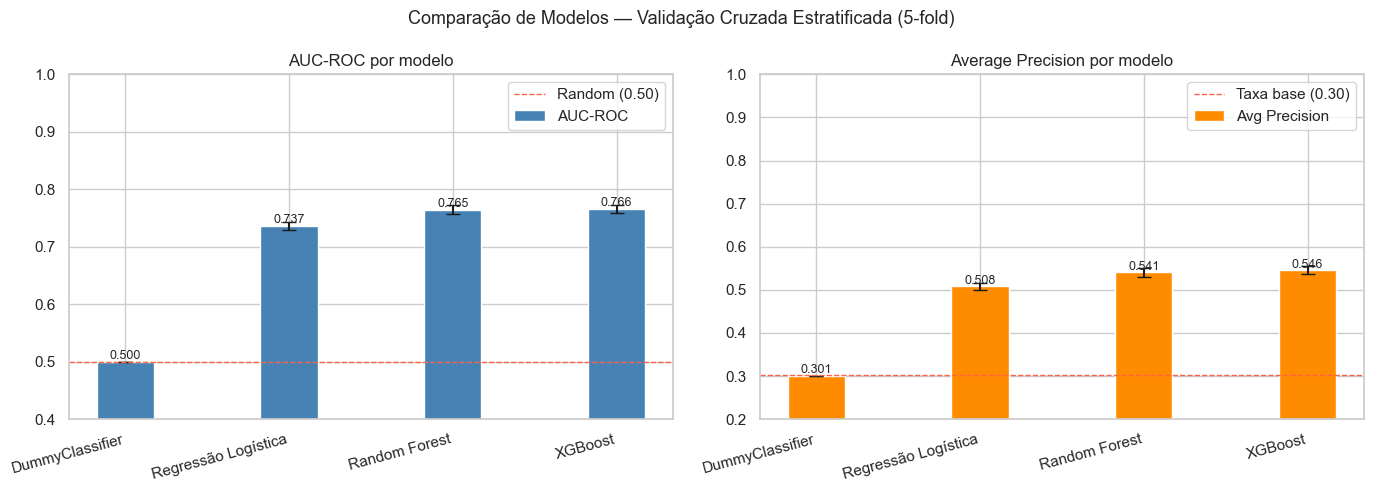

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos  = df_resultados.index.tolist()
x        = np.arange(len(modelos))
width    = 0.35

# AUC-ROC
axes[0].bar(x, df_resultados['auc_roc'], width,
            yerr=df_resultados['auc_roc_std'], capsize=5,
            color='steelblue', edgecolor='white', label='AUC-ROC')
axes[0].axhline(0.5, color='tomato', linestyle='--', linewidth=1, label='Random (0.50)')
axes[0].set_title('AUC-ROC por modelo')
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos, rotation=15, ha='right')
axes[0].set_ylim(0.4, 1.0)
axes[0].legend()
for i, v in enumerate(df_resultados['auc_roc']):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

# Average Precision
axes[1].bar(x, df_resultados['avg_precision'], width,
            yerr=df_resultados['avg_precision_std'], capsize=5,
            color='darkorange', edgecolor='white', label='Avg Precision')
axes[1].axhline(0.3025, color='tomato', linestyle='--', linewidth=1,
                label='Taxa base (0.30)')
axes[1].set_title('Average Precision por modelo')
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos, rotation=15, ha='right')
axes[1].set_ylim(0.2, 1.0)
axes[1].legend()
for i, v in enumerate(df_resultados['avg_precision']):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Comparação de Modelos — Validação Cruzada Estratificada (5-fold)',
             fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / 'comparacao_modelos.png', dpi=120)
plt.show()


💡 **Observação:**

A tabela e os gráficos acima mostram média ± desvio padrão dos 5 folds. O desvio padrão indica a **estabilidade** do modelo — um desvio alto sugere sensibilidade à partição dos dados.

O modelo com maior **Average Precision** é o preferido para este problema, pois é mais sensível ao desbalanceamento e reflete melhor a performance na classe de interesse (cancelamentos).


# 📉 9. Avaliação Final no Conjunto de Teste

Nesta etapa, as curvas ROC e Precision-Recall são plotadas para o modelo campeão, treinado no dataset completo. Essas curvas mostram o comportamento do modelo em todos os thresholds possíveis — não apenas em 0.5.


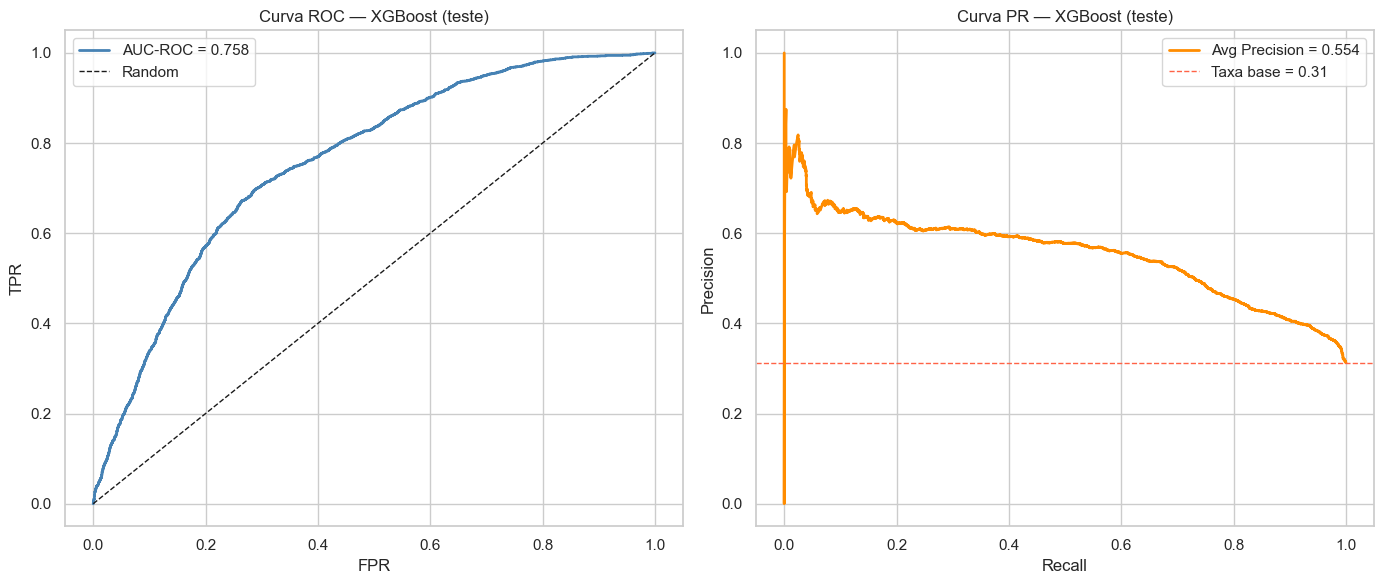

AUC-ROC no teste: 0.7582 | Average Precision no teste: 0.5542


In [10]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Modelo campeão identificado na seção anterior
modelo_campeao = xgb
nome_campeao   = 'XGBoost'

# Treina no conjunto de treino e avalia no conjunto de teste
modelo_campeao.fit(X_train, y_train)
y_prob_test = modelo_campeao.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'AUC-ROC = {roc_auc:.3f}')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
axes[0].set_title(f'Curva ROC — {nome_campeao} (teste)')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend()

# PR
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(rec, prec)
axes[1].plot(rec, prec, color='darkorange', linewidth=2,
             label=f'Avg Precision = {pr_auc:.3f}')
axes[1].axhline(y_test.mean(), color='tomato', linestyle='--', linewidth=1,
                label=f'Taxa base = {y_test.mean():.2f}')
axes[1].set_title(f'Curva PR — {nome_campeao} (teste)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / 'curvas_roc_pr.png', dpi=120)
plt.show()
print(f'AUC-ROC no teste: {roc_auc:.4f} | Average Precision no teste: {pr_auc:.4f}')


# 🎯 9. Análise de Threshold — Trade-off Operacional

Nesta etapa, é analisado o impacto do threshold de decisão na operação. O threshold padrão de 0,5 raramente é o ótimo para problemas de negócio.

**Contexto operacional:**
- **Falso Positivo (FP):** fiscal acionado para uma ordem que seria executada — custo de deslocamento desnecessário
- **Falso Negativo (FN):** cancelamento não detectado — serviço não vistoriado, cliente insatisfeito, penalidade contratual

O threshold ideal depende do custo relativo entre FP e FN, definido pelo negócio.


In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

# y_prob_test e y_test já definidos na seção anterior
thresholds = np.arange(0.1, 0.9, 0.05)
rows = []
for t in thresholds:
    y_pred = (y_prob_test >= t).astype(int)
    rows.append({
        'threshold':  round(t, 2),
        'precision':  precision_score(y_test, y_pred, zero_division=0),
        'recall':     recall_score(y_test, y_pred, zero_division=0),
        'f1':         f1_score(y_test, y_pred, zero_division=0),
        'n_alertas':  int(y_pred.sum()),
        'tp':         int(((y_pred == 1) & (y_test == 1)).sum()),
        'fp':         int(((y_pred == 1) & (y_test == 0)).sum()),
        'fn':         int(((y_pred == 0) & (y_test == 1)).sum()),
    })

df_thresh = pd.DataFrame(rows)
display(df_thresh.set_index('threshold'))


,precision,recall,f1,n_alertas,tp,fp,fn
threshold,,,,,,,
0.1000,0.3379,0.9927,0.5041,6414,2167,4247,16
0.1500,0.3565,0.9840,0.5233,6026,2148,3878,35
0.2000,0.3729,0.9647,0.5379,5647,2106,3541,77
0.2500,0.3846,0.9464,0.5469,5372,2066,3306,117
0.3000,0.3942,0.9363,0.5548,5185,2044,3141,139
0.3500,0.4033,0.9107,0.5591,4929,1988,2941,195
0.4000,0.4193,0.8745,0.5668,4553,1909,2644,274
0.4500,0.4454,0.8131,0.5756,3985,1775,2210,408
0.5000,0.4818,0.7513,0.5871,3404,1640,1764,543


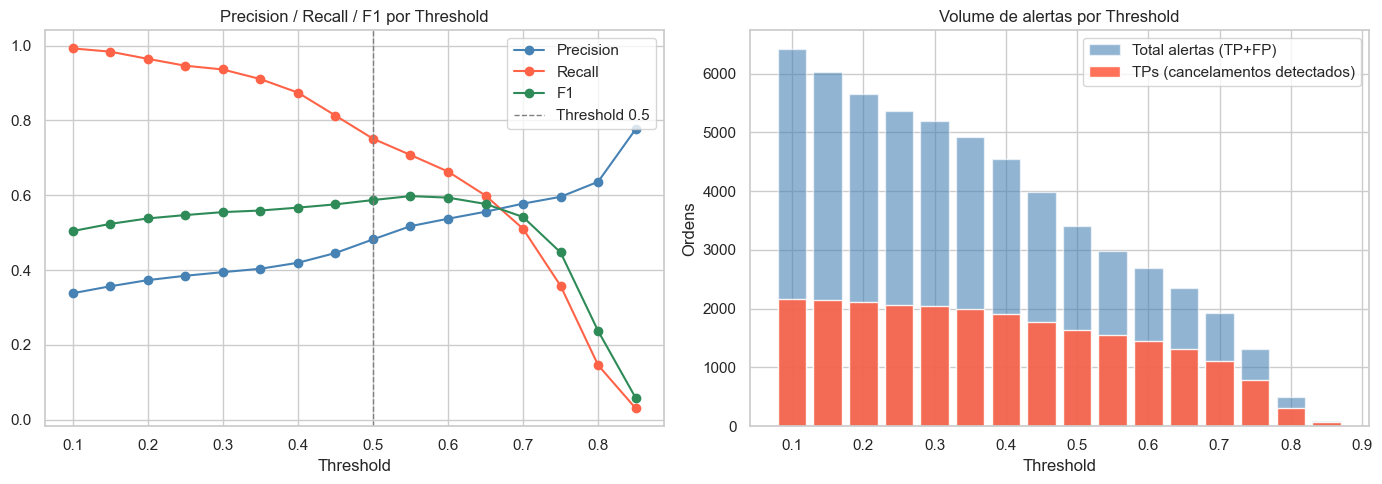

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision, Recall e F1 por threshold
axes[0].plot(df_thresh['threshold'], df_thresh['precision'],
             marker='o', label='Precision', color='steelblue')
axes[0].plot(df_thresh['threshold'], df_thresh['recall'],
             marker='o', label='Recall', color='tomato')
axes[0].plot(df_thresh['threshold'], df_thresh['f1'],
             marker='o', label='F1', color='seagreen')
axes[0].axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Threshold 0.5')
axes[0].set_title('Precision / Recall / F1 por Threshold')
axes[0].set_xlabel('Threshold')
axes[0].legend()

# Volume de alertas e TPs por threshold
axes[1].bar(df_thresh['threshold'], df_thresh['n_alertas'],
            width=0.04, color='steelblue', alpha=0.6, label='Total alertas (TP+FP)')
axes[1].bar(df_thresh['threshold'], df_thresh['tp'],
            width=0.04, color='tomato', alpha=0.9, label='TPs (cancelamentos detectados)')
axes[1].set_title('Volume de alertas por Threshold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Ordens')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / 'analise_threshold.png', dpi=120)
plt.show()


💡 **Observação:**

A tabela e os gráficos acima mostram o trade-off completo. Para escolher o threshold:

1. **Se o custo do FN for muito maior que o FP** (penalidade contratual grave) → usar threshold baixo (~0,3), priorizando Recall
2. **Se o custo do FP for significativo** (fiscal tem capacidade limitada) → usar threshold mais alto (~0,5–0,6), priorizando Precision
3. **Ponto de equilíbrio** → threshold onde F1 é máximo

> Esta decisão deve ser tomada junto ao negócio com dados reais de custo operacional.


# 🔍 10. Importância de Features — SHAP

Nesta etapa, os SHAP values são calculados para o modelo campeão, permitindo entender **quais features mais influenciam** cada predição e em qual direção. SHAP é a técnica de interpretabilidade mais robusta para modelos de gradient boosting.


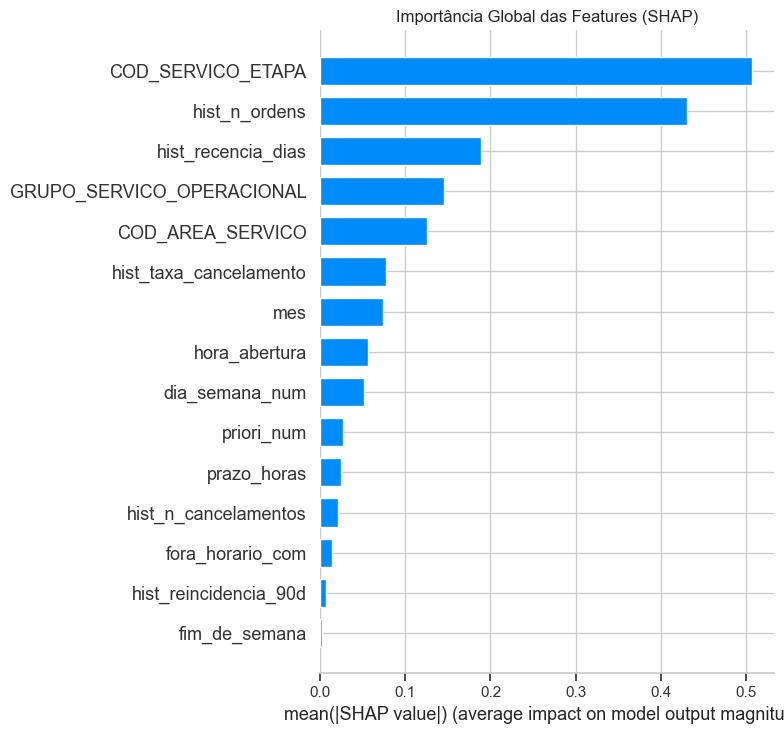

In [13]:
import shap

# modelo_campeao já treinado em X_train na seção anterior
# Transforma X_test com o preprocessador ajustado
X_test_transformed = modelo_campeao.named_steps['pre'].transform(X_test)
feature_names_out = (
    CAT_COLS +  # TargetEncoder mantém a ordem das colunas
    NUM_COLS
)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names_out)

explainer   = shap.TreeExplainer(modelo_campeao.named_steps['clf'])
shap_values = explainer.shap_values(X_test_transformed_df)

# Summary plot — importância global e direção
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_transformed_df, plot_type='bar', show=False)
plt.title('Importância Global das Features (SHAP)')
plt.tight_layout()
plt.savefig(FIGURES / 'shap_importancia.png', dpi=120, bbox_inches='tight')
plt.show()


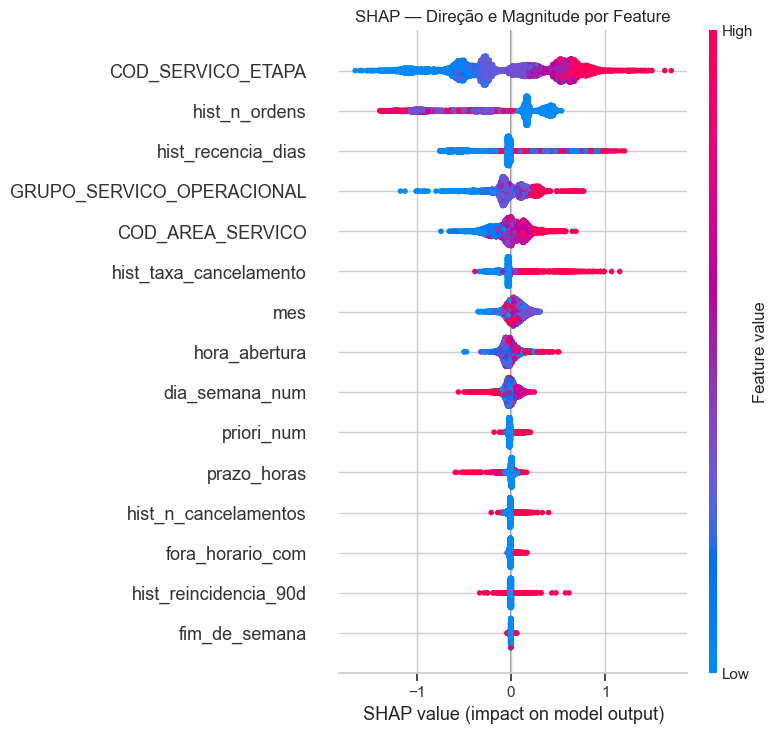

In [14]:
# Beeswarm plot — direção e magnitude do impacto por feature
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_transformed_df, show=False)
plt.title('SHAP — Direção e Magnitude por Feature')
plt.tight_layout()
plt.savefig(FIGURES / 'shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()


💡 **Observação:**

**Como ler o beeswarm:**
- Cada ponto é uma ordem de serviço
- **Posição no eixo X:** impacto no score de cancelamento (positivo = aumenta probabilidade)
- **Cor:** valor da feature (vermelho = alto, azul = baixo)

**Achados esperados com base na EDA:**
| Feature | Direção esperada |
|---------|------------------|
| `te_grupo_servico_operacional` alto | → aumenta P(cancelamento) |
| `priori_num` baixo (prioridade 1) | → aumenta P(cancelamento) |
| `prazo_horas` baixo (24h/48h) | → aumenta P(cancelamento) |
| `hist_taxa_cancelamento` alto | → aumenta P(cancelamento) |
| `hist_reincidencia_90d` alto | → aumenta P(cancelamento) |

Se os achados do SHAP contradizerem a EDA, revisar a feature engineering e verificar possível leakage.
